In [2]:
import image_creator

from matplotlib import pyplot as plt
import numpy as np
import astropy.units as u

In [37]:
def power_law_sed(lambda_values, alpha):
    # Calculate the flux density using the power-law SED formula
    flux_density = (lambda_values / 5500 * u.AA) ** (-alpha)
    return flux_density

lambda_values = np.linspace(91, 1e8, 10000) * u.AA
flux_density = power_law_sed(lambda_values, alpha=1.5)

Text(0, 0.5, '$\\lambda\\cdot F_\\lambda$(erg/s/cm²)')

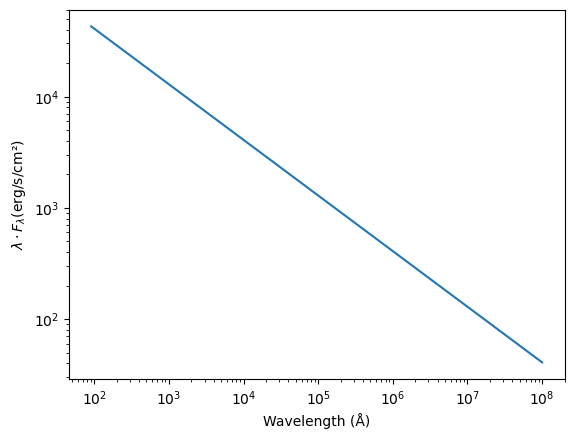

In [39]:
plt.plot(lambda_values, flux_density*lambda_values)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Wavelength (Å)')
plt.ylabel(r'$\lambda\cdot F_\lambda$(erg/s/cm²)')

In [40]:
SED_paths = {'source': f'./inputs/SEDs/sed_observed_star_forming.csv', 'lens': f'./inputs/SEDs/Ell13_template_norm.csv'}
color_maker = image_creator.SED_color_calculator(SED_paths)

In [41]:
z = 2.0

lambda_values_redshifted = lambda_values * (1 + z)
power_law_SED_redshifted = flux_density / (1 + z)

star_forming_lambda_redshifted, star_forming_flux_redshifted = color_maker.redshift(color_maker.SEDs['source'], z)

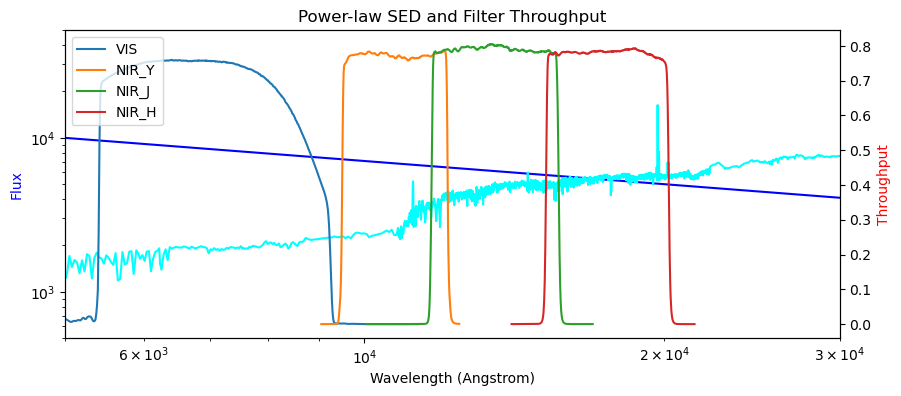

In [42]:
filters_names = color_maker.filter_names

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(lambda_values_redshifted, power_law_SED_redshifted * lambda_values_redshifted, color='blue', label='SED')
ax1.plot(star_forming_lambda_redshifted, star_forming_flux_redshifted * star_forming_lambda_redshifted, color='cyan', label='Source SED')
ax1.set_xlabel('Wavelength (Angstrom)')
ax1.set_ylabel('Flux', color='blue')
ax1.set_yscale('log')

ax2 = ax1.twinx()
for i, filter_throughput in enumerate(color_maker.filter_throughputs):
    ax2.plot(filter_throughput[0], filter_throughput[1], label=f'{filters_names[i]}')
    ax2.set_ylabel('Throughput', color='red')

ax1.set_yscale('log')
ax1.set_ylim(5e2, 5e4)

ax2.legend(loc='upper left')

plt.xscale('log')

plt.xlim(5e3, 3e4)
plt.title('Power-law SED and Filter Throughput')

plt.show()